CSV oluşturuldu: ai_monthly_papers.csv


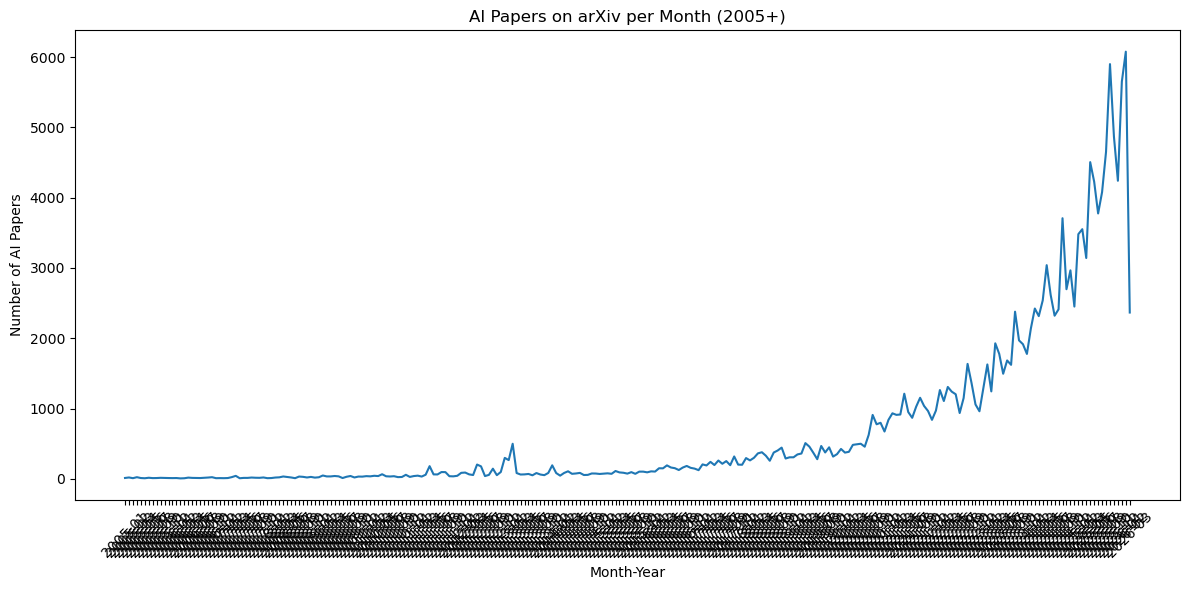

In [1]:
from sickle import Sickle
from collections import defaultdict
import csv
import matplotlib.pyplot as plt

# OAI-PMH bağlantısı
sickle = Sickle('https://oaipmh.arxiv.org/oai')

# Sadece AI kategorisini çekiyoruz
records = sickle.ListRecords(
    metadataPrefix='arXiv',
    set='cs:cs:AI'
)

# Ay-yıl sayacı
monthly_counts = defaultdict(int)

for record in records:

    data = record.metadata

    if not data:
        continue

    # makale tarihi
    date = data["created"][0]

    year = int(date[:4])

    # sadece 2005 sonrası
    if year < 2005:
        continue

    # YYYY-MM formatı
    month = date[:7]

    monthly_counts[month] += 1


# CSV oluşturma
with open("ai_monthly_papers.csv", "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["month", "paper_count"])

    for m in sorted(monthly_counts):
        writer.writerow([m, monthly_counts[m]])


print("CSV oluşturuldu: ai_monthly_papers.csv")


# Grafik çizme
months = sorted(monthly_counts.keys())
values = [monthly_counts[m] for m in months]

plt.figure(figsize=(12,6))
plt.plot(months, values)
plt.xlabel("Month-Year")
plt.ylabel("Number of AI Papers")
plt.title("AI Papers on arXiv per Month (2005+)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

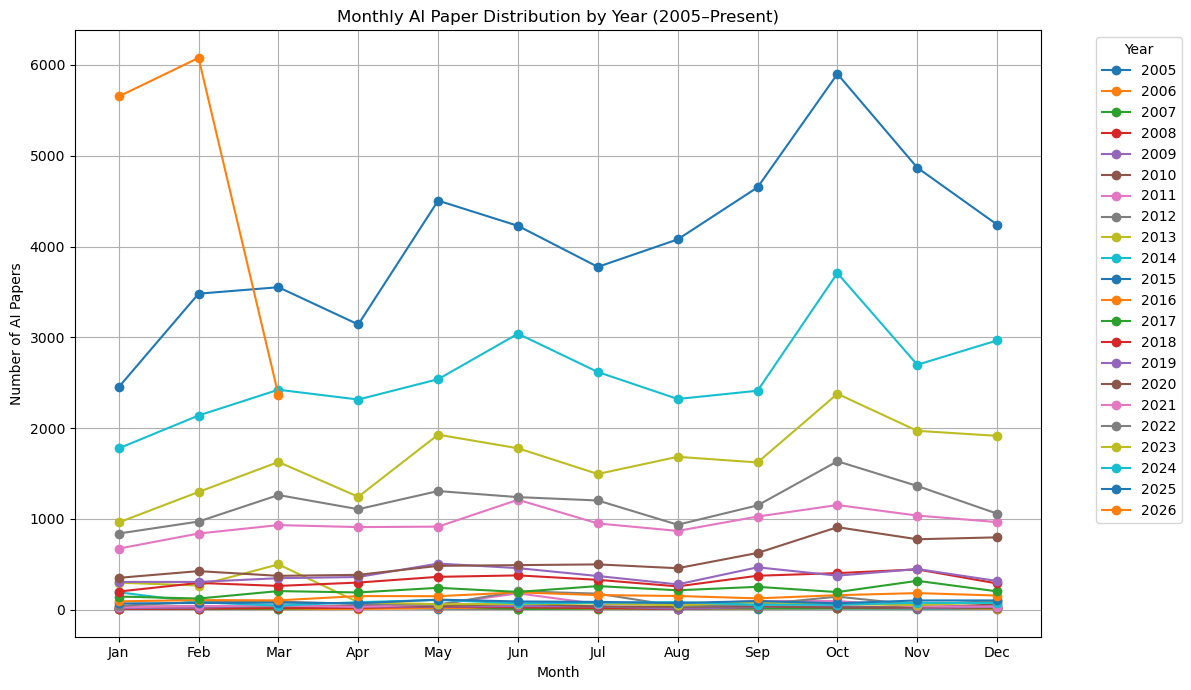

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# CSV oku
df = pd.read_csv("ai_monthly_papers.csv")

# yıl ve ay ayır
df["year"] = df["month"].str[:4].astype(int)
df["month_num"] = df["month"].str[5:7].astype(int)

# ay isimleri
month_names = [
    "Jan","Feb","Mar","Apr","May","Jun",
    "Jul","Aug","Sep","Oct","Nov","Dec"
]

plt.figure(figsize=(12,7))

# her yıl için çizgi
for year in sorted(df["year"].unique()):

    year_data = df[df["year"] == year]

    plt.plot(
        year_data["month_num"],
        year_data["paper_count"],
        marker="o",
        linewidth=1.5,
        label=str(year)
    )

plt.xlabel("Month")
plt.ylabel("Number of AI Papers")
plt.title("Monthly AI Paper Distribution by Year (2005–Present)")

plt.xticks(range(1,13), month_names)

plt.legend(
    title="Year",
    bbox_to_anchor=(1.05,1),
    loc="upper left"
)

plt.grid(True)

plt.tight_layout()

plt.show()

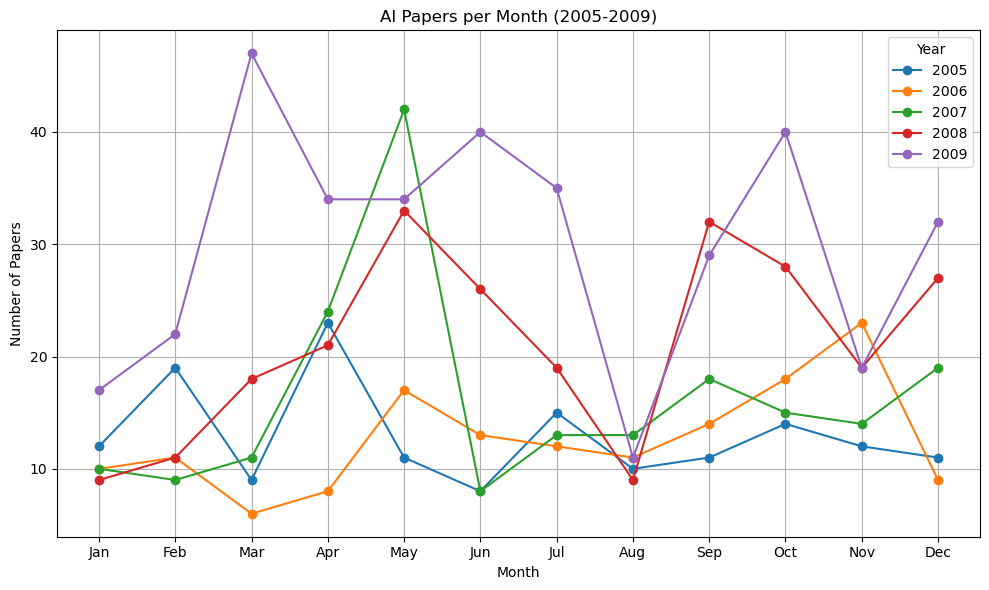

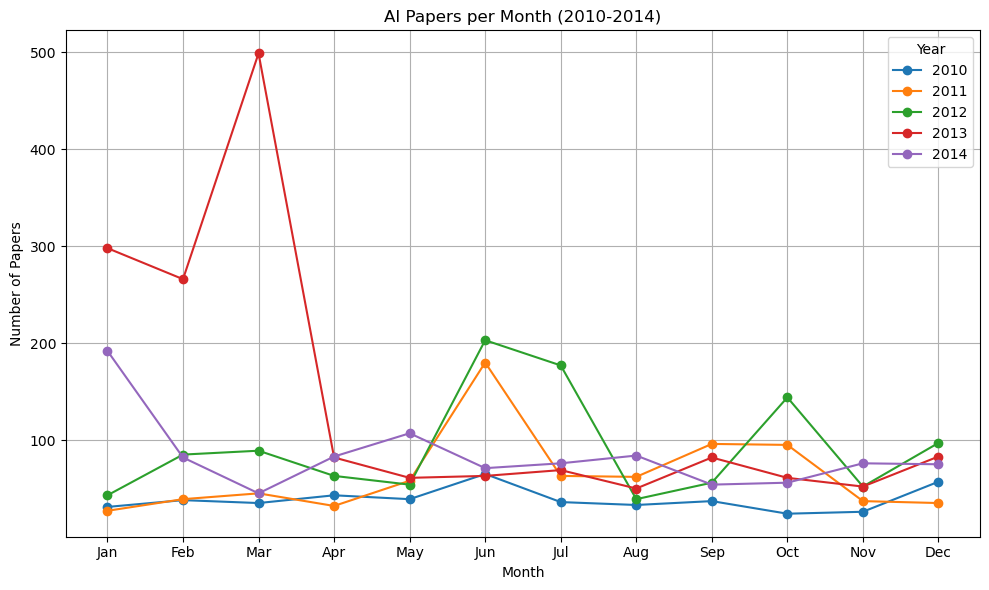

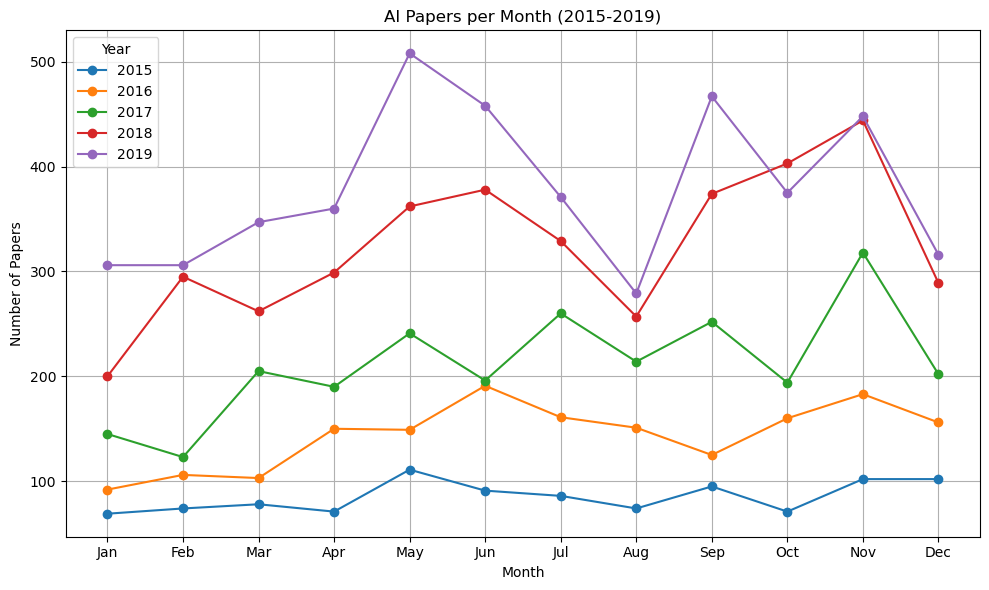

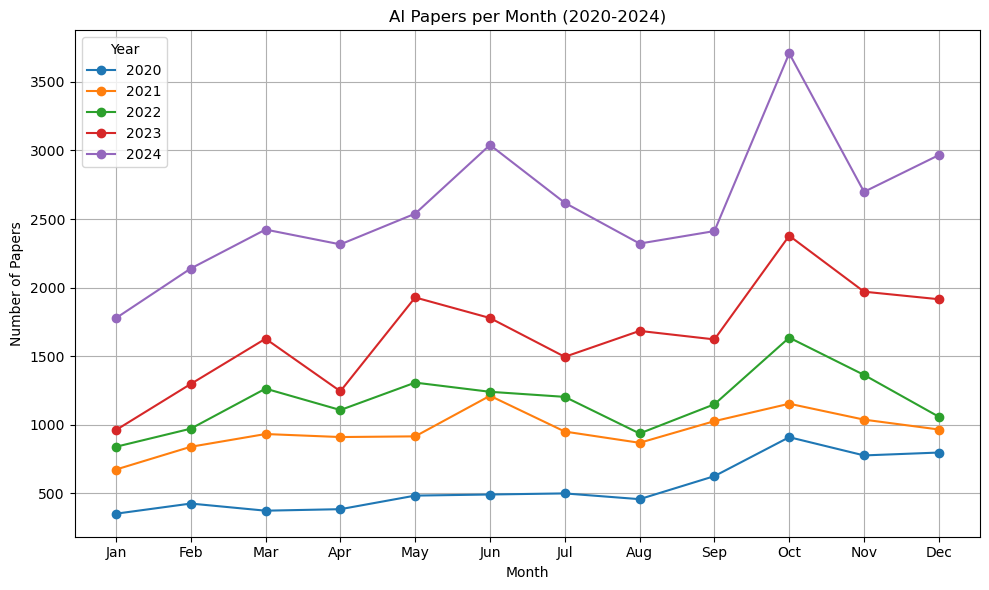

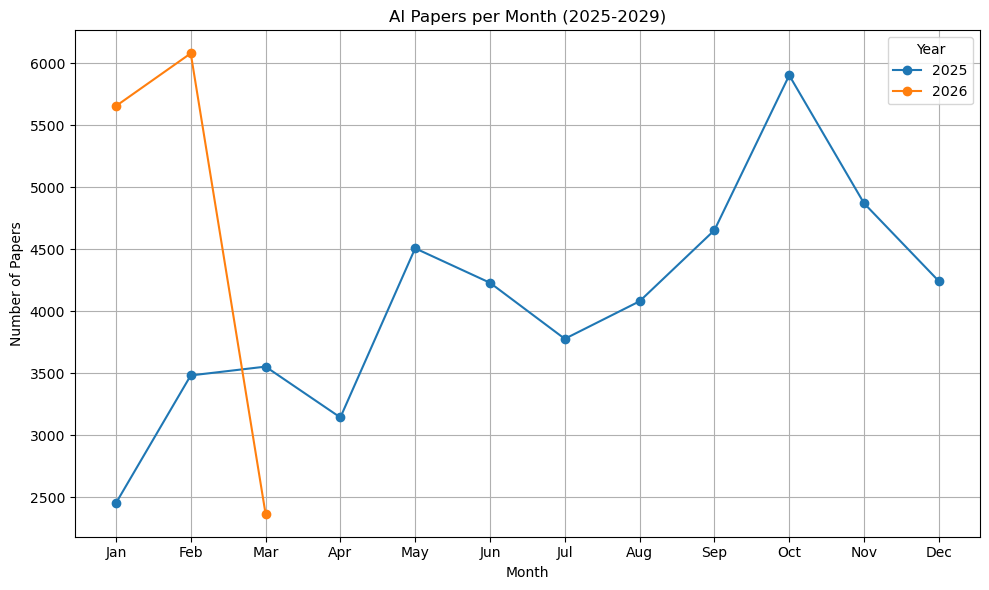

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# CSV yükle
df = pd.read_csv("ai_monthly_papers.csv")

# tarih sütunlarını ayır
df["year"] = df["month"].str[:4].astype(int)
df["month_num"] = df["month"].str[5:7].astype(int)

# ay isimleri
month_names = [
    "Jan","Feb","Mar","Apr","May","Jun",
    "Jul","Aug","Sep","Oct","Nov","Dec"
]

# 5 yıllık aralıklar
start_year = df["year"].min()
end_year = df["year"].max()

windows = []

for y in range(start_year, end_year, 5):
    windows.append((y, y+4))

# her pencere için grafik çiz
for start, end in windows:

    subset = df[(df["year"] >= start) & (df["year"] <= end)]

    plt.figure(figsize=(10,6))

    for year in sorted(subset["year"].unique()):

        year_data = subset[subset["year"] == year]

        plt.plot(
            year_data["month_num"],
            year_data["paper_count"],
            marker="o",
            label=str(year)
        )

    plt.title(f"AI Papers per Month ({start}-{end})")
    plt.xlabel("Month")
    plt.ylabel("Number of Papers")

    plt.xticks(range(1,13), month_names)

    plt.legend(title="Year")

    plt.grid(True)

    plt.tight_layout()

    plt.show()